Purpose: Examine results of third-degree polynomial modeling by physiotype & treatment for genes of various families related to CAM, photorespiration, the circadian clock, nitrogen metabolism, & citrate metabolism.<br>
Author: Anna Pardo<br>
Date initiated: June 26, 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# load results dataframe
res = pd.read_csv("../polymod3_res_all_pathways_Jun2026.txt",sep="\t",header="infer")
res.head()

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F),Model,GeneID,GeneName,FDR_p,subgenome,gene_family,FDR_p_largen
0,823,803.430222,NaN,NaN,NaN,NaN,polyZT,Yucal.01G302600.v2.1,Ya_PGP_1,NaN,Ya,PGP,NaN
1,815,734.489239,8.0,68.940983,14.017729,3.414170e-19,polyZT*treat,Yucal.01G302600.v2.1,Ya_PGP_1,4.916404e-18,Ya,PGP,4.800848e-18
2,819,594.973157,-4.0,139.516083,NaN,NaN,polyZT*phys,Yucal.01G302600.v2.1,Ya_PGP_1,NaN,Ya,PGP,NaN
3,803,493.657070,16.0,101.316087,10.300270,4.563035e-24,polyZT*treat*phys,Yucal.01G302600.v2.1,Ya_PGP_1,1.546064e-22,Ya,PGP,1.438143e-22
4,823,739.235519,NaN,NaN,NaN,NaN,polyZT,Yucal.22G052300.v2.1,Ya_PGP_2,NaN,Ya,PGP,NaN


In [3]:
# note: should use the 'FDR_p_largen' column rather than 'FDR_p'
resna = res.dropna()

In [4]:
resna.head()

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F),Model,GeneID,GeneName,FDR_p,subgenome,gene_family,FDR_p_largen
1,815,734.489239,8.0,68.940983,14.017729,3.414170e-19,polyZT*treat,Yucal.01G302600.v2.1,Ya_PGP_1,4.916404e-18,Ya,PGP,4.800848e-18
3,803,493.657070,16.0,101.316087,10.300270,4.563035e-24,polyZT*treat*phys,Yucal.01G302600.v2.1,Ya_PGP_1,1.546064e-22,Ya,PGP,1.438143e-22
5,815,692.210228,8.0,47.025291,7.761204,4.602497e-10,polyZT*treat,Yucal.22G052300.v2.1,Ya_PGP_2,1.949293e-09,Ya,PGP,2.003182e-09
7,803,608.174169,16.0,63.891671,5.272442,1.141195e-10,polyZT*treat*phys,Yucal.22G052300.v2.1,Ya_PGP_2,5.432464e-10,Ya,PGP,5.432562e-10
9,815,731.630834,8.0,6.458132,1.376648,2.028848e-01,polyZT*treat,YufilH1006999m.g,Yf_PGP_1,2.291405e-01,Yf,PGP,2.292172e-01


In [5]:
# find significant results
sigres = resna[resna["FDR_p"]<0.05]

In [6]:
# drop model polyZT (baseline)
nobase = sigres[sigres["Model"]!="polyZT"]

In [7]:
len(resna["GeneName"].unique())

333

In [8]:
len(nobase["GeneName"].unique())

280

In [9]:
# for each gene that does have significant results: make a table showing which model(s) were significant/their FDR p-values
## (this can go in the supplement for the paper)
dfdict = {"Gene Name":[],"Gene ID":[],"ZT*Treatment":[],"ZT*Physiology":[],"ZT*Treatment*Physiology":[]}
for i in sigres["GeneName"].unique():
    dfdict['Gene Name'].append(i)
    df = sigres[sigres["GeneName"]==i]
    #print(df)
    dfdict['Gene ID'].append(df["GeneID"].unique()[0])
    
    if "polyZT*phys" in list(df["Model"]):
        dfdict['ZT*Physiology'].append(df.loc[df['Model'] == "polyZT*phys", 'FDR_p'].iloc[0])
    else:
        dfdict['ZT*Physiology'].append("not significant")
        
    if "polyZT*treat" in list(df["Model"]):
        dfdict['ZT*Treatment'].append(df.loc[df['Model'] == "polyZT*treat", 'FDR_p'].iloc[0])
    else:
        dfdict['ZT*Treatment'].append("not significant")
        
    if "polyZT*treat*phys" in list(df["Model"]):
        dfdict['ZT*Treatment*Physiology'].append(df.loc[df['Model'] == "polyZT*treat*phys", 'FDR_p'].iloc[0])
    else:
        dfdict['ZT*Treatment*Physiology'].append("not significant")

In [10]:
genesigs = pd.DataFrame(dfdict)
genesigs.head()

,Gene Name,Gene ID,ZT*Treatment,ZT*Physiology,ZT*Treatment*Physiology
0,Ya_PGP_1,Yucal.01G302600.v2.1,0.0,not significant,0.0
1,Ya_PGP_2,Yucal.22G052300.v2.1,0.0,not significant,0.0
2,Yf_PGP_1,YufilH1006999m.g,not significant,not significant,0.000225
3,Yf_PGP_2,YufilH1040717m.g,0.0,0.0,0.0
4,Yf_PGP_3,YufilH1084368m.g,0.0,0.0,0.0


In [11]:
# make a Gene Family column
genesigs["Gene Family"] = genesigs["Gene Name"].str.split("_").str[1]
genesigs.head()

,Gene Name,Gene ID,ZT*Treatment,ZT*Physiology,ZT*Treatment*Physiology,Gene Family
0,Ya_PGP_1,Yucal.01G302600.v2.1,0.0,not significant,0.0,PGP
1,Ya_PGP_2,Yucal.22G052300.v2.1,0.0,not significant,0.0,PGP
2,Yf_PGP_1,YufilH1006999m.g,not significant,not significant,0.000225,PGP
3,Yf_PGP_2,YufilH1040717m.g,0.0,0.0,0.0,PGP
4,Yf_PGP_3,YufilH1084368m.g,0.0,0.0,0.0,PGP


In [12]:
# load the various pathway annotations
camannot = pd.read_csv("../camgenes_Ya_Yf_orthology_synteny.txt",sep="\t",header="infer")
camannot.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [13]:
clock = pd.read_csv("../circadian_light_genes_by_orthology_Yucca.csv",sep=",",header="infer")
clock.head()

,GeneID,Orthogroup,gene_name,subgenome,gene_name_unique
0,Yucal.11G006100.v2.1,OG0002937,TOC1,Ya,Ya_TOC1_1
1,Yucal.15G098200.v2.1,OG0002937,TOC1,Ya,Ya_TOC1_2
2,Yucal.16G106200.v2.1,OG0002937,TOC1,Ya,Ya_TOC1_3
3,YufilH1057026m.g,OG0002937,TOC1,Yf,Yf_TOC1_1
4,YufilH1057027m.g,OG0002937,TOC1,Yf,Yf_TOC1_2


In [14]:
prncit = pd.read_csv("../photresp_N_citrate_genes_Yucca.csv",sep=",",header="infer")
prncit.head()

,Pathway,gene_family,GeneID,subgenome,gene_name_unique
0,PhotResp,PGP,Yucal.01G302600.v2.1,Ya,Ya_PGP_1
1,PhotResp,PGP,Yucal.22G052300.v2.1,Ya,Ya_PGP_2
2,PhotResp,PGP,YufilH1006999m.g,Yf,Yf_PGP_1
3,PhotResp,PGP,YufilH1040717m.g,Yf,Yf_PGP_2
4,PhotResp,PGP,YufilH1084368m.g,Yf,Yf_PGP_3


In [15]:
clock["Pathway"] = "Clock"

In [16]:
# stick all pathway annotations together
allpath = pd.concat([
    prncit[["gene_family","Pathway"]].drop_duplicates(),
    clock[["gene_name","Pathway"]].drop_duplicates().rename(columns={"gene_name":"gene_family"}),
    camannot[["gene_abbr","Pathway"]].drop_duplicates().rename(columns={"gene_abbr":"gene_family"})
])
allpath.head()

,gene_family,Pathway
0,PGP,PhotResp
5,GOX,PhotResp
21,GGT/GGAT,PhotResp
25,"SHMT6,7",PhotResp
33,"SHMT1,2",PhotResp


In [17]:
genesigs = genesigs.merge(allpath.rename(columns={"gene_family":"Gene Family"}))
genesigs.head()

,Gene Name,Gene ID,ZT*Treatment,ZT*Physiology,ZT*Treatment*Physiology,Gene Family,Pathway
0,Ya_PGP_1,Yucal.01G302600.v2.1,0.0,not significant,0.0,PGP,PhotResp
1,Ya_PGP_2,Yucal.22G052300.v2.1,0.0,not significant,0.0,PGP,PhotResp
2,Yf_PGP_1,YufilH1006999m.g,not significant,not significant,0.000225,PGP,PhotResp
3,Yf_PGP_2,YufilH1040717m.g,0.0,0.0,0.0,PGP,PhotResp
4,Yf_PGP_3,YufilH1084368m.g,0.0,0.0,0.0,PGP,PhotResp


In [18]:
# save this table
genesigs.to_csv("./allpathways_polymod_byphys_pvals_table.csv",sep=",",header=True,index=False)

In [19]:
# add pathway info to results
resna = resna.merge(allpath)
resna.head()

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F),Model,GeneID,GeneName,FDR_p,subgenome,gene_family,FDR_p_largen,Pathway
0,815,734.489239,8.0,68.940983,14.017729,3.414170e-19,polyZT*treat,Yucal.01G302600.v2.1,Ya_PGP_1,4.916404e-18,Ya,PGP,4.800848e-18,PhotResp
1,803,493.657070,16.0,101.316087,10.300270,4.563035e-24,polyZT*treat*phys,Yucal.01G302600.v2.1,Ya_PGP_1,1.546064e-22,Ya,PGP,1.438143e-22,PhotResp
2,815,692.210228,8.0,47.025291,7.761204,4.602497e-10,polyZT*treat,Yucal.22G052300.v2.1,Ya_PGP_2,1.949293e-09,Ya,PGP,2.003182e-09,PhotResp
3,803,608.174169,16.0,63.891671,5.272442,1.141195e-10,polyZT*treat*phys,Yucal.22G052300.v2.1,Ya_PGP_2,5.432464e-10,Ya,PGP,5.432562e-10,PhotResp
4,815,731.630834,8.0,6.458132,1.376648,2.028848e-01,polyZT*treat,YufilH1006999m.g,Yf_PGP_1,2.291405e-01,Yf,PGP,2.292172e-01,PhotResp


In [20]:
# fix Model column
resna["Model"] = resna["Model"].map({"polyZT*treat":"treatment","polyZT*treat*phys":"treatment*physiotype",
                                "polyZT*phys":"physiotype"})
resna["Model"] = pd.Categorical(resna["Model"],["treatment","physiotype","treatment*physiotype"])
resna.sort_values("Model",inplace=True)
resna.head()

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F),Model,GeneID,GeneName,FDR_p,subgenome,gene_family,FDR_p_largen,Pathway
0,815,734.489239,8.0,68.940983,14.017729,3.414170e-19,treatment,Yucal.01G302600.v2.1,Ya_PGP_1,4.916404e-18,Ya,PGP,4.800848e-18,PhotResp
383,815,683.282681,8.0,54.462987,9.146213,4.312203e-12,treatment,YufilH1012121m.g,Yf_NADP-IDH_4,2.483829e-11,Yf,NADP-IDH,2.478839e-11,CA-cycle
819,815,790.506173,8.0,8.554433,1.109956,3.539122e-01,treatment,Yucal.15G017000.v2.1,Ya_PPCK_6,3.916069e-01,Ya,PPCK,3.837197e-01,CAM-dark
380,815,720.447988,8.0,10.725013,1.514363,1.481409e-01,treatment,YufilH1003419m.g,Yf_NADP-IDH_2,1.720346e-01,Yf,NADP-IDH,1.716106e-01,CA-cycle
378,815,512.239897,8.0,11.075938,2.390208,1.503209e-02,treatment,Yucal.21G081400.v2.1,Ya_NADP-IDH_5,2.101574e-02,Ya,NADP-IDH,2.097608e-02,CA-cycle


In [21]:
pathmap = {}
for i in resna["Pathway"].unique():
    if i.startswith("CAM"):
        pathmap[i] = "CAM"
    else:
        pathmap[i] = i
        
# change Pathway column
resna["Pathway"] = resna["Pathway"].map(pathmap)

In [22]:
# ensure there will be same ordering with sharey=True
yares = resna[resna["subgenome"]=="Ya"][["Pathway","gene_family","GeneName","Model","FDR_p"]]
yfres = resna[resna["subgenome"]=="Yf"][["Pathway","gene_family","GeneName","Model","FDR_p"]]

In [23]:
yares.sort_values(by=["Model","Pathway","gene_family"],inplace=True)
yares.head()

,Pathway,gene_family,GeneName,Model,FDR_p
298,CA-cycle,ACO,Ya_ACO_4,treatment,2.792284e-06
296,CA-cycle,ACO,Ya_ACO_3,treatment,1.445591e-03
293,CA-cycle,ACO,Ya_ACO_2,treatment,9.562007e-11
290,CA-cycle,ACO,Ya_ACO_1,treatment,2.156843e-03
301,CA-cycle,ACO,Ya_ACO_5,treatment,1.915442e-01


In [24]:
yfres.sort_values(by=["Model","Pathway","gene_family"],inplace=True)
yfres.head()

,Pathway,gene_family,GeneName,Model,FDR_p
318,CA-cycle,ACO,Yf_ACO_16,treatment,8.148589e-08
316,CA-cycle,ACO,Yf_ACO_15,treatment,1.481524e-01
313,CA-cycle,ACO,Yf_ACO_10,treatment,8.366248e-09
311,CA-cycle,ACO,Yf_ACO_6,treatment,8.080734e-02
308,CA-cycle,ACO,Yf_ACO_2,treatment,3.830514e-04


In [25]:
# figure plotting function
def plot_pathway(path,d="./"):
    yapath = yares[yares["Pathway"]==path]
    yfpath = yfres[yfres["Pathway"]==path]
    
    fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(14,10),sharex=True,sharey=True)
    ax[0].axvline(x=0.05)
    sns.boxplot(ax=ax[0],data=yapath,y="gene_family",x="FDR_p",hue="Model")
    sns.stripplot(ax=ax[0],data=yapath,y="gene_family",x="FDR_p",hue="Model")
    ax[0].set_title("Y. aloifolia origin (CAM)",fontsize=20)
    ax[0].tick_params(which="both",labelsize=16)
    ax[0].set_ylabel("Gene Family",fontsize=16)
    ax[0].set_xlabel("FDR-adjusted p value",fontsize=16)
    ax[0].get_legend().remove()

    ax[1].axvline(x=0.05)
    sns.boxplot(ax=ax[1],data=yfpath,y="gene_family",x="FDR_p",hue="Model")
    sns.stripplot(ax=ax[1],data=yfpath,y="gene_family",x="FDR_p",hue="Model")
    ax[1].set_title("Y. filamentosa origin (C3)",fontsize=20)
    ax[1].tick_params(which="both",labelsize=16)
    ax[1].set_ylabel("")
    ax[1].set_xlabel("FDR-adjusted p value",fontsize=16)

    fig.tight_layout()

    if not os.path.exists(d):
        os.makedirs(d)
        
    fname = path+"_polymod_byphysTA_pvals"
    plt.savefig(os.path.join(d,fname+".png"),dpi=300,bbox_inches="tight")
    plt.savefig(os.path.join(d,fname+".pdf"),dpi=300,bbox_inches="tight")
    plt.savefig(os.path.join(d,fname+".svg"),dpi=300,bbox_inches="tight")

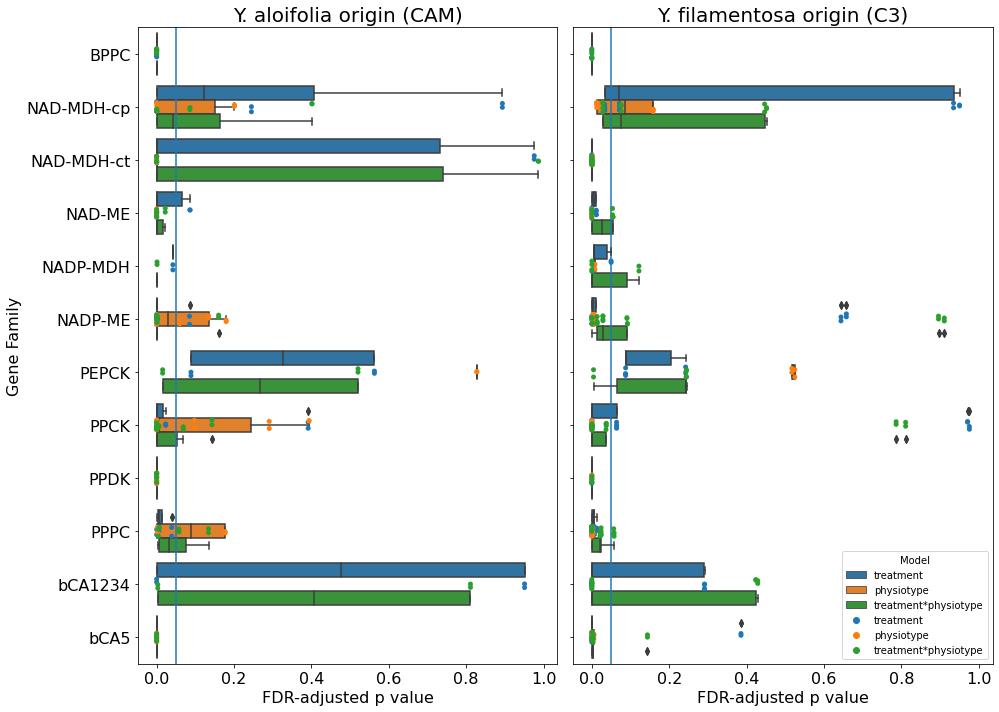

In [26]:
plot_pathway("CAM",d="./polynomial_modeling_pvals_bypathway")

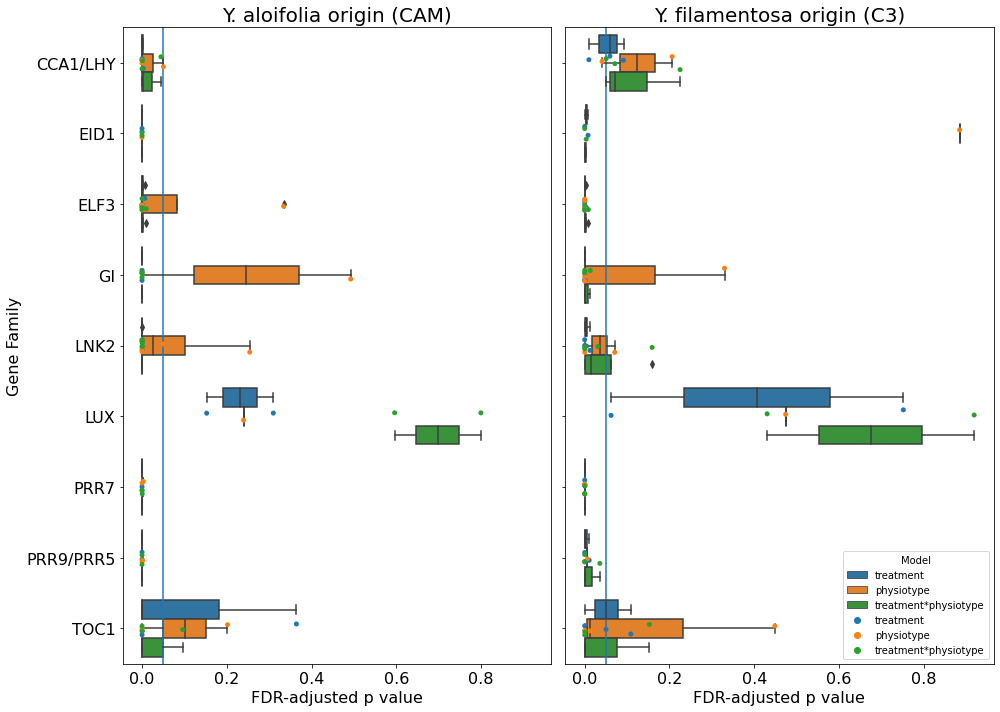

In [29]:
plot_pathway("Clock","./polynomial_modeling_pvals_bypathway")

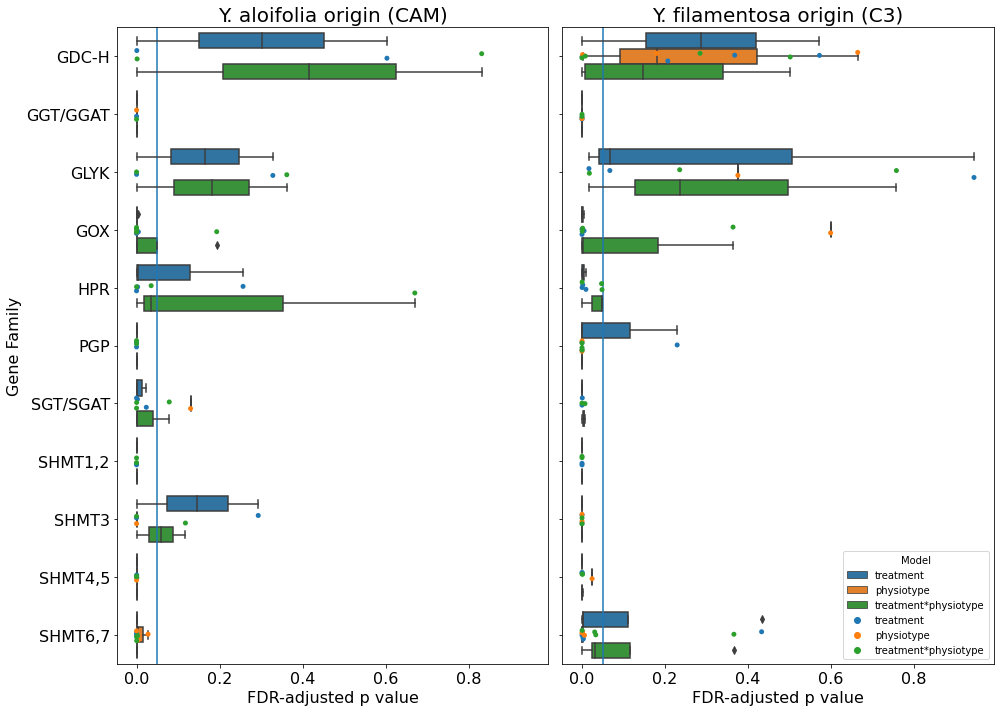

In [35]:
plot_pathway("PhotResp","./polynomial_modeling_pvals_bypathway")

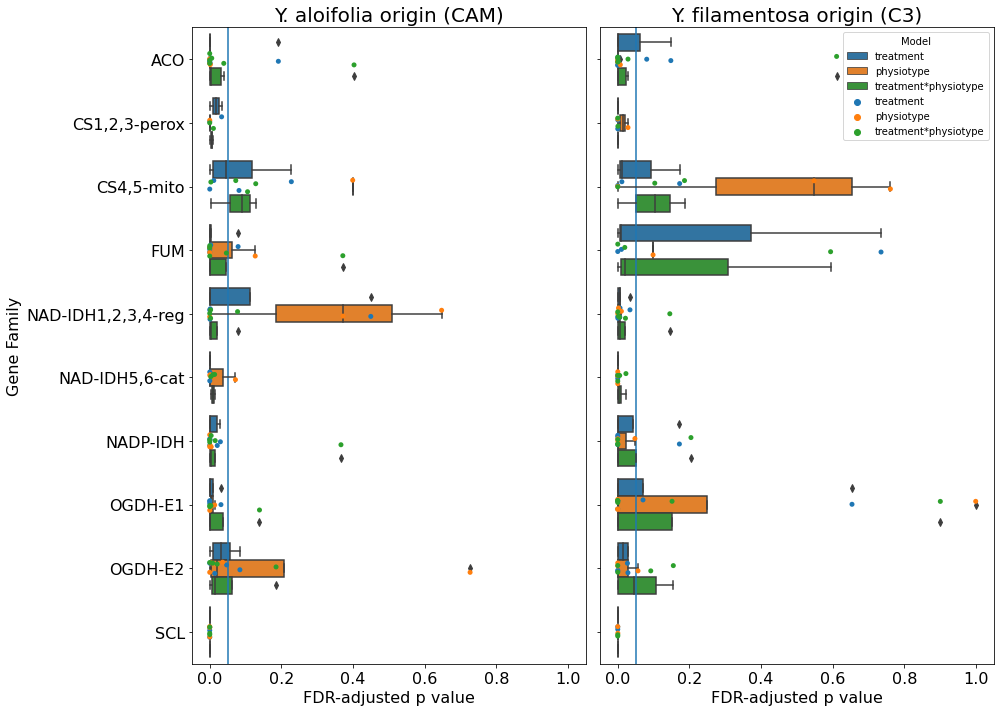

In [36]:
plot_pathway("CA-cycle","./polynomial_modeling_pvals_bypathway")

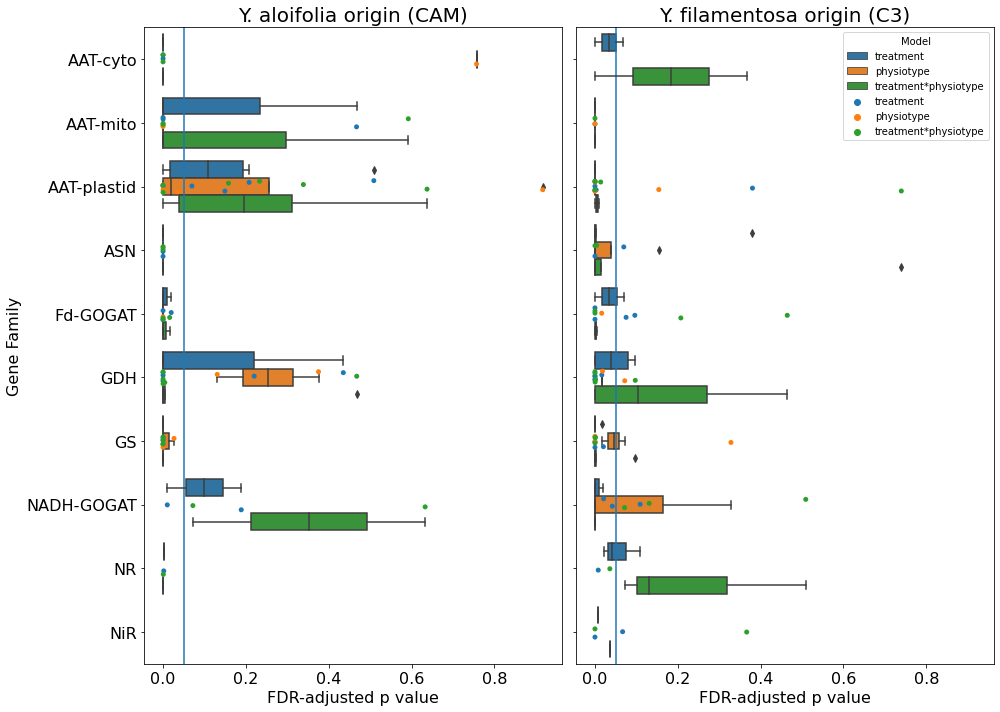

In [37]:
plot_pathway("N-metab","./polynomial_modeling_pvals_bypathway")